# Batch velocity-FFT post-processing of PIVlab runs

Loops over every sub-folder of `BASE_DIR`, loads the PIV `.mat`, calibrates the
field, and -- for each region (`ROI` / `FULL`) -- computes, for **every grid
point** in the region, the single-sided **FFT amplitude spectrum** of `U(t)` and
`V(t)` (`np.fft.rfft`, mean removed, Hann window with coherent-gain correction),
then **averages the per-point spectra over the region**.

Per run it writes `<run>/PostProcessing/VelocityFFT_<region>.npz` (`f`, `amp_u`,
`amp_v`, `amp_total = amp_u + amp_v`, their `_star` = `/U0` versions, the ROI
power spectra and polarization statistics), a spectrum figure
`VelocityFFT_<region>[_normalized].<fmt>` (the **total** amplitude only, dashed
guides at `f_rot`, `f_lib` / `2 f_lib` and, when significant, `f_low` /
`f_lib∓f_low`, and black diamonds sitting on the curve at each detected peak),
and a polarization figure `Velocity_polarization_<region>[_normalized].<fmt>`.

It locates `f_peak` (dominant peak of the summed spectrum) and `f_low` (strongest
peak in `[F_LOW_FMIN, f_lib/2]`, kept only if it exceeds `THRESHOLD_PEAK ×` the
band mean -- otherwise `f_low` and its `f_lib∓f_low` sidebands are `NaN`), and
records the summed-spectrum amplitude at `f_lib`, `f_low`, `f_lib−f_low`,
`f_lib+f_low` (raw and `/U0`).

Across all runs it writes one `VelocityFFT_summary_<region>.csv` at `BASE_DIR`
(with the `kept` de-duplication -- one run per `frot/flib/dphi`, the highest
`SSn`) and, when `SAVE_COLORMAP`, dataset colormaps of the ROI-averaged spectrum
vs `f*`, `δφ` and `f_lib`.

Calibration, ROI and file names come from the dataset's
`param_postProcessing.json` (the PIV field rate is `fps = cam_fps / 2`, since
PIVlab pairs images). Set the config in the next cell, then *Run All*;
`ONLY_RUNS` restricts to a few folders for testing.

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import get_window
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

%matplotlib widget

from piv_postprocessing_lib import (topography_arrangement, amp_at_freq, compute_polarization,
                        dimensionless_numbers,
                        fft_axis_limits, fft_guide_lines, figure_filename,
                        libration_velocity_scale, load_piv, parse_run_name,
                        peak_freq, peak_freq_in_band, read_acquisition_params,
                        read_paramPostprocessing, region_fields, region_tag,
                        regions_to_run)


In [2]:
# --- Mute switch -----------------------------------------------------------
# MUTE_PRINT = True silences ALL print() output (this notebook AND the library),
# so a running batch stays quiet while you edit other files. Re-run this cell to
# toggle. (Figures are unaffected.)
import builtins
if not hasattr(builtins, "_piv_real_print"):
    builtins._piv_real_print = builtins.print

MUTE_PRINT = True

builtins.print = (lambda *a, **k: None) if MUTE_PRINT else builtins._piv_real_print

# --- Configuration --------------------------------------------------------- #
BASE_DIR = ("/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/"
            "TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_topBottom")  # top-level folder containing the runs

# --- FFT settings ---------------------------------------------------------- #
# Per-point single-sided amplitude spectrum of U(t) and V(t) over the FULL
# record (np.fft.rfft). Finest resolution df = fps / nframes, but no segment
# averaging (noisier than Welch).
FFT_WINDOW = "hann"     # taper before the FFT to suppress spectral leakage;
                        # "boxcar" or None -> no window. Coherent gain is divided
                        # out so amplitudes stay calibrated.
FFT_DETREND = "constant"   # "constant" removes the per-point mean (kills DC);
                           # None keeps it.

# f_low: the strongest peak of |FFT(U)|+|FFT(V)| in [F_LOW_FMIN, f_lib/2], i.e.
# the low-frequency response well below the libration forcing. Recorded in the
# summary as f_low_Hz and marked on the per-run figure together with the
# sidebands f_lib -/+ f_low. The lower bound keeps the near-DC bins (residual
# drift, finite record length) out of the search.
F_LOW_FMIN = 0.06       # Hz
THRESHOLD_PEAK = 1.5    # f_low is significant only if its amplitude exceeds
                        # THRESHOLD_PEAK * mean amplitude over the search band
                        # [F_LOW_FMIN, f_lib/2]; otherwise f_low (and the
                        # f_lib -/+ f_low sidebands and all their amplitudes)
                        # are set to NaN.

# Log X (frequency) and Y (amplitude) axes on the per-run spectrum figures.
LOGX = False
LOGY = True

# --- Colormap settings ----------------------------------------------------- #
# Which velocity component to show in the colormap:
#   "u"      -> fft(U)         amplitude |FFT(U)|
#   "v"      -> fft(V)         amplitude |FFT(V)|
#   "total"  -> fft(U)+fft(V)  summed amplitude
#   "powerU" -> |FFT(U)|^2     ROI-averaged power spectrum of U
#   "powerV" -> |FFT(V)|^2     ROI-averaged power spectrum of V
PLOT_COMPONENT = "total"

# Restrict which runs enter the plots. Maps a summary column to an allowed value
# (or list of values); {} -> use every run. Examples:
#   {"dphi_deg": 2}                 -> only dphi = 2 deg
#   {"dphi_deg": [2, 3]}            -> dphi in {2, 3} deg
#   {"dphi_deg": 2, "frot_Hz": 0.5}-> dphi = 2 deg AND frot = 0.5 Hz
PLOT_FILTER = {}
PLOT_NFREQ = 400        # rows of the common frequency grid for the colormap
PLOT_FMAX = None        # y-axis max (Hz, or f/f_rot if normalised). None -> auto
PLOT_CMAP = "viridis"

# --- "x = dphi" colormap (at fixed f_lib) ---------------------------------- #
# Libration frequency (Hz) to hold fixed for the dphi colormap. None -> the
# first flib found in VelocityFFT_summary; the run cell prints the full list.
PLOT_FIX_FLIB = 1.5

# For the "x = f_lib" colormap: which dphi (deg) to hold fixed. None -> the
# first dphi found in the summary; the run cell prints the full list.
PLOT_FIX_DPHI = 2

###########################################################################################

# Dataset parameters from param_postProcessing.json in BASE_DIR (also rebinds
# them inside piv_postprocessing_lib for its helpers).
_P = read_paramPostprocessing(BASE_DIR)
k0 = _P.k0
TOP_TOPO, BOTTOM_TOPO = topography_arrangement(BASE_DIR)
PIV_FILENAME, LOG_FILENAME = _P.PIV_FILENAME, _P.LOG_FILENAME
XSCALE, YSCALE = _P.XSCALE, _P.YSCALE
PTS_ROI = _P.PTS_ROI
UNCAL_SCALE = _P.UNCAL_SCALE

RESULT_STEM   = "VelocityFFT"                # per-run output -> <stem>_<region>.npz
SUMMARY_STEM  = "VelocityFFT_summary"        # summary -> <stem>_<region>.csv
POLFIG_STEM   = "Velocity_polarization"      # per-run polarization figure

# Which region(s) to process: 'BOTH' (ROI and FULL), 'ROI' only, or 'FULL' only.
REGION      = 'ROI'

# Which processed region the colormap cells at the end display ('ROI' or 'FULL').
REGION_PLOT = "ROI"

# Only runs without an existing result are processed unless this is True.
REPROCESS_ALL = True

# Saved-figure format: 'png' or 'pdf'. Every figure is written twice
# -- a raw version and a '_normalized' one.
FIG_FORMAT = 'png'

# Save the colormap overview figures (VelocityFFT_colormap_*)? False -> they are
# still drawn interactively but not written to disk.
SAVE_COLORMAP = False

# Restrict processing to these run-folder names (for testing). Empty -> all runs.
ONLY_RUNS = []

In [3]:
def _interp_nan_rows(A):
    """Linearly interpolate NaNs along time for each row (point) of A.

    A has shape (npoints, nframes). Rows that are entirely NaN are flagged in the
    returned `keep` mask (they are excluded from the ROI average). Interior /
    edge NaNs are filled by linear interpolation (edges use the nearest value).
    """
    A = A.astype(float, copy=True)
    n = A.shape[1]
    idx = np.arange(n)
    keep = np.ones(A.shape[0], dtype=bool)
    for i in range(A.shape[0]):
        row = A[i]
        m = np.isnan(row)
        if m.all():
            keep[i] = False
            continue
        if m.any():
            row[m] = np.interp(idx[m], idx[~m], row[~m])
    return A, keep


def _amp_spectrum(A, window=FFT_WINDOW, detrend=FFT_DETREND):
    """Single-sided FFT amplitude spectrum along the last axis.

    A has shape (npoints, nframes). Returns an array (npoints, nfreq) of
    amplitudes: |rfft| divided by the window's coherent gain (so a pure tone
    reads its true amplitude), then doubled for every bin except DC and, for an
    even-length record, Nyquist. The mean is removed first when detrend is
    "constant".
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[-1]
    if detrend == "constant":
        A = A - np.nanmean(A, axis=-1, keepdims=True)
    if window and window != "boxcar":
        w = get_window(window, n)
    else:
        w = np.ones(n)
    cg = w.sum()                       # coherent gain -> amplitude-correct scaling
    F = np.fft.rfft(A * w, axis=-1)
    amp = np.abs(F) / cg
    if amp.shape[-1] > 1:
        amp[..., 1:] *= 2.0            # single-sided: fold negative frequencies
        if n % 2 == 0:
            amp[..., -1] /= 2.0        # Nyquist bin is not doubled
    return amp



def _power_spectrum(A, window=FFT_WINDOW, detrend=FFT_DETREND):
    """Raw FFT power spectrum |rfft|**2 along the last axis.

    A has shape (npoints, nframes). The mean is removed (detrend="constant")
    and the same window as the amplitude spectrum is applied, then power =
    np.abs(rfft)**2 (no single-sided doubling / coherent-gain scaling; this is
    the power definition used for the polarization ratio powerV/powerU).
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[-1]
    if detrend == "constant":
        A = A - np.nanmean(A, axis=-1, keepdims=True)
    if window and window != "boxcar":
        w = get_window(window, n)
    else:
        w = np.ones(n)
    F = np.fft.rfft(A * w, axis=-1)
    return np.abs(F) ** 2


def averaged_fft(u_roi, v_roi, fps, window=FFT_WINDOW, detrend=FFT_DETREND):
    """ROI-averaged single-sided amplitude spectrum of U(t) and V(t).

    For every grid point in the ROI the amplitude spectrum of its time series is
    computed with np.fft.rfft, then averaged over all valid points.
    Returns (f, amp_u, amp_v, amp_total, powerU, powerV, npoints) where
    amp_total = amp_u+amp_v (amplitudes, m/s) and powerU/powerV are the
    ROI-averaged power spectra |FFT|**2 of each component (m^2/s^2). Returns
    NaNs if no valid point exists.
    """
    nf = u_roi.shape[-1]
    U = u_roi.reshape(-1, nf)
    V = v_roi.reshape(-1, nf)
    U, keepU = _interp_nan_rows(U)
    V, keepV = _interp_nan_rows(V)

    f = np.fft.rfftfreq(nf, d=1.0 / fps)
    if not keepU.any() or not keepV.any():
        nanv = np.full_like(f, np.nan, dtype=float)
        return (f, nanv, nanv.copy(), nanv.copy(),
                nanv.copy(), nanv.copy(), 0)

    Au = _amp_spectrum(U[keepU], window, detrend)
    Av = _amp_spectrum(V[keepV], window, detrend)
    amp_u = np.nanmean(Au, axis=0)
    amp_v = np.nanmean(Av, axis=0)
    amp_total = amp_u + amp_v

    # ROI-averaged power spectra |FFT|**2 of each component.
    powerU = np.nanmean(_power_spectrum(U[keepU], window, detrend), axis=0)
    powerV = np.nanmean(_power_spectrum(V[keepV], window, detrend), axis=0)

    npoints = int(keepU.sum())
    return f, amp_u, amp_v, amp_total, powerU, powerV, npoints



def roi_polarization_stats(u_roi, v_roi, fps, window=FFT_WINDOW,
                           detrend=FFT_DETREND):
    """ROI statistics of the velocity-polarization ratio powerV/powerU.

    Definitions (per grid point, |.| = np.abs, all vs the one-sided FFT grid f):
      powerU = |FFT(U)|**2 , powerV = |FFT(V)|**2 .
    All spectra use the same detrend + window as the amplitude spectrum.
    Returns a dict with:
      powerU_mean, powerV_mean : ROI mean of powerU / powerV
      powerRatio, powerRatio_std: ROI mean/std of the per-point powerV/powerU
      powerRatio_med           : ROI median of the per-point powerV/powerU
      powerRatio_p25, powerRatio_p75 : ROI 25/75 percentiles of that ratio
      f, npoints
    """
    nf = u_roi.shape[-1]
    U = u_roi.reshape(-1, nf)
    V = v_roi.reshape(-1, nf)
    U, keepU = _interp_nan_rows(U)
    V, keepV = _interp_nan_rows(V)
    keep = keepU & keepV
    f = np.fft.rfftfreq(nf, d=1.0 / fps)
    nanv = np.full_like(f, np.nan, dtype=float)
    out = {"f": f, "npoints": int(keep.sum())}
    keys = ("powerU_mean", "powerV_mean", "powerRatio", "powerRatio_std",
            "powerRatio_med", "powerRatio_p25", "powerRatio_p75")
    if not keep.any():
        for k in keys:
            out[k] = nanv.copy()
        return out

    Uk = U[keep]
    Vk = V[keep]

    # (1) power spectra |FFT|**2 per point and their ROI mean.
    pU = _power_spectrum(Uk, window, detrend)
    pV = _power_spectrum(Vk, window, detrend)
    powerU_mean = np.nanmean(pU, axis=0)
    powerV_mean = np.nanmean(pV, axis=0)

    # (2) per-point power ratio powerV/powerU, then ROI statistics.
    with np.errstate(divide="ignore", invalid="ignore"):
        rp = pV / pU
    rp[~np.isfinite(rp)] = np.nan
    powerRatio = np.nanmean(rp, axis=0)
    powerRatio_std = np.nanstd(rp, axis=0)
    # Median + 25-75 percentiles: a log-axis-friendly, skew-robust ROI spread.
    powerRatio_med = np.nanmedian(rp, axis=0)
    powerRatio_p25 = np.nanpercentile(rp, 25, axis=0)
    powerRatio_p75 = np.nanpercentile(rp, 75, axis=0)

    out.update(powerU_mean=powerU_mean, powerV_mean=powerV_mean,
               powerRatio=powerRatio, powerRatio_std=powerRatio_std,
               powerRatio_med=powerRatio_med, powerRatio_p25=powerRatio_p25,
               powerRatio_p75=powerRatio_p75)
    return out

In [4]:
def build_row(name, out_file, processed, region=np.nan, fps=np.nan,
              nframes=np.nan, npoints=np.nan, f_peak=np.nan, f_low=np.nan,
              dt_vel=np.nan, ok=np.nan, peak_amp=None, peak_amp_star=None):
    """Assemble one summary-table row (folder-name metadata + results/flags)."""
    frot_hz, flib_hz, dphi_deg = parse_run_name(name)
    fstar = flib_hz / frot_hz if frot_hz else np.nan
    # Session index: the integer following 'SS' in the folder name (SS2 -> 2).
    ss = re.search(r"SS(\d+)", name)
    run_idx = int(ss.group(1)) if ss else np.nan
    # Dimensionless numbers + normalised (_star) frequencies (/ frot).
    dl = dimensionless_numbers(frot_hz, flib_hz, dphi_deg)
    fn = frot_hz if np.isfinite(frot_hz) and frot_hz else np.nan
    row = {"run": name, "run idx": run_idx, "region": region,
           "processed": processed, "frot_Hz": frot_hz, "flib_Hz": flib_hz,
           "dphi_deg": dphi_deg, "fstar": fstar, "flib_star": fstar,
           "calibrated": ok, "dt_vel_s": dt_vel, "fps_Hz": fps,
           "nframes": nframes, "npoints": npoints,
           "f_peak_Hz": f_peak, "f_peak_star": f_peak / fn,
           "f_low_Hz": f_low, "f_low_star": f_low / fn,
           "top_topo": TOP_TOPO, "bottom_topo": BOTTOM_TOPO, "npz": out_file}
    # Amplitude of the summed spectrum at f_lib, f_low and the f_lib -/+ f_low
    # sidebands -- raw (m/s) and normalised by U0.
    _pa = peak_amp or {}
    _pas = peak_amp_star or {}
    for _k in ("flib", "flow", "flib_minus_flow", "flib_plus_flow"):
        row["amp_%s" % _k] = _pa.get(_k, np.nan)
        row["amp_%s_star" % _k] = _pas.get(_k, np.nan)
    row.update(dl)
    return row


def _save_fft_figure(out_png, f, amp_u, amp_v, amp_total, name, calibrated,
                     f_peak, frot=None, flib=None, f_low=None, dphi_deg=None,
                     normalize=False):
    """Save a per-run figure of the ROI-averaged FFT amplitude spectra.

    Written next to the run's .npz. Log-log axes; the DC bin (f = 0) is dropped.
    Dashed guides mark f_rot (blue), f_lib and 2*f_lib (red), and the
    low-frequency peak f_low with its sidebands f_lib -/+ f_low (green); each
    carries its value in the legend. f_peak is stated in the title.
    normalize=True divides the amplitudes by U0 and the frequency axis by f_rot.
    Closed immediately so a batch does not leave many windows open.
    """
    funit = "Hz" if calibrated else "1/frame"
    aunit = r"m\,s^{-1}" if calibrated else r"px/frame"
    U0 = (libration_velocity_scale(dphi_deg, flib)
          if flib and dphi_deg is not None else np.nan)
    ascale = U0 if (normalize and calibrated and np.isfinite(U0) and U0) else 1.0
    fscale = frot if (normalize and frot and np.isfinite(frot)) else 1.0
    at = amp_total / ascale
    ff = f / fscale
    _frot = frot / fscale if frot else frot
    _flib = flib / fscale if flib else flib
    _flow = f_low / fscale if (f_low is not None and np.isfinite(f_low)) else f_low
    _fpk = f_peak / fscale if np.isfinite(f_peak) else f_peak
    _fu = "" if fscale != 1.0 else " %s" % funit
    m = f > 0
    fig, ax = plt.subplots(figsize=(8, 5))
    _plot = ax.semilogy if LOGY else ax.plot
    if np.any(m):
        _plot(ff[m], at[m], color="C0", lw=1.2,
              label=r"$|\widehat{U}|+|\widehat{V}|$")
    ax.set_xlabel(r"$f / f_{\mathrm{rot}}$" if fscale != 1.0
                  else "frequency (%s)" % funit, fontsize=12)
    ax.set_ylabel(r"ROI-averaged amplitude $/\,U_0$" if ascale != 1.0
                  else r"ROI-averaged amplitude  ($\mathrm{%s}$)" % aunit, fontsize=12)
    title = name + ("   (normalized)" if normalize else "") \
        + "   ($k_0 = %g$, top=%s, bottom=%s)" % (k0, TOP_TOPO, BOTTOM_TOPO)
    if np.isfinite(_fpk) and _fpk > 0:
        title += "      $f_{\mathrm{peak}}$ = %.4g%s" % (_fpk, _fu)
    ax.set_title(title, fontsize=12)
    ax.grid(True, which="both", ls=":", alpha=0.4)
    # Frequency axis to [0, max(4*frot,4*flib)]; y to decade bounds.
    _xmax, _ymin, _ymax = fft_axis_limits(ff, [at], _frot, _flib)
    # y lower bound: the closest power of 10 below the minimum of the visible
    # total amplitude (keeps the whole curve in view on the log axis).
    _vis = at[(f > 0) & (ff <= _xmax) & (at > 0)]
    if _vis.size:
        _ymin = 10.0 ** np.floor(np.log10(_vis.min()))
    if LOGX:
        ax.set_xscale("log")
        _pos = ff[(ff > 0) & (ff <= _xmax)]
        ax.set_xlim(_pos.min() if _pos.size else _xmax / 100.0, _xmax)
    else:
        ax.set_xlim(0, _xmax)
    if _ymin and _ymax:
        ax.set_ylim(_ymin, _ymax)
    # Reference frequencies: colour-coded by family, value in the legend. Drawn
    # after the limits are set so the off-scale ones are dropped.
    for fq, lbl, colr in fft_guide_lines(_frot, _flib, _flow):
        if fq > _xmax:
            continue
        ax.axvline(fq, color=colr, ls="--", lw=1.0, alpha=0.85,
                   label="%s = %.4g%s" % (lbl, fq, _fu))
    # Black diamonds at the detected peaks (f_lib, f_low, f_lib -/+ f_low), at
    # the total amplitude *on the plotted curve* (interpolated at each exact
    # frequency) so every marker sits exactly on the total-amplitude line.
    _pk = []
    if _flib is not None and np.isfinite(_flib):
        _pk.append(_flib)
    if _flow is not None and np.isfinite(_flow):
        _pk.append(_flow)
        if _flib is not None and np.isfinite(_flib):
            _pk += [_flib - _flow, _flib + _flow]
    _dlbl = False
    for _pf in _pk:
        if not (0.0 <= _pf <= _xmax):
            continue
        _pa = float(np.interp(_pf, ff, at))
        if np.isfinite(_pa):
            ax.plot(_pf, _pa, "D", color="k", ms=6, zorder=5,
                    label=None if _dlbl else "detected peaks")
            _dlbl = True
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)


def _save_polarization_v2_figure(out_png, f, pol, frot, name, normalize=False):
    """Polarization figure next to the .npz (log y-axis).

    Overlays the inertial-wave relation 2*((2*frot/f)**2 - 1) with the measured
    powerV/powerU ratio over the ROI, shown both as the ROI mean and as the
    median with a shaded 25-75 percentile band. The ratio is dimensionless, so
    normalize=True only rescales the frequency axis to f/f_rot (0.01..1 Hz).
    """
    fscale = frot if (normalize and frot and np.isfinite(frot)) else 1.0
    ff = f / fscale
    m = f > 0
    fig, ax = plt.subplots(figsize=(9, 6))
    if frot:
        theory = 2.0 * ((2.0 * frot / f[m]) ** 2 - 1.0)
        ax.plot(ff[m], theory, "k-", lw=2.2,
                label=r"$2[(2f_{\mathrm{rot}}/f)^2-1]$  (IW)")
    # powerV/powerU over the ROI: both the plain ROI mean and the median with
    # a shaded 25-75 percentile band (skew-robust, always positive -> sensible
    # on a log axis).
    ax.plot(ff[m], pol["powerRatio"][m], lw=1.2, label=r"mean $P_V/P_U$")
    line, = ax.plot(ff[m], pol["powerRatio_med"][m], lw=1.2,
                    label=r"median $P_V/P_U$")
    ax.fill_between(ff[m], pol["powerRatio_p25"][m], pol["powerRatio_p75"][m],
                    color=line.get_color(), alpha=0.20, lw=0,
                    label="ROI 25-75%")
    ax.set_yscale("log")
    ax.set_xlim(0.01 / fscale, 1.0 / fscale)
    ax.set_xlabel(r"$f / f_{\mathrm{rot}}$" if fscale != 1.0 else "frequency (Hz)",
                  fontsize=12)
    ax.set_ylabel(r"polarization  $P_V/P_U$", fontsize=12)
    ax.set_title("Polarization - %s%s   ($k_0 = %g$, top=%s, bottom=%s)"
                 % (name, "   (normalized)" if normalize else "", k0,
                    TOP_TOPO, BOTTOM_TOPO),
                 fontsize=12)
    ax.grid(True, which="both", ls=":", alpha=0.4)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)


def process_run(run_dir, region, reprocess=False):
    """Process one run folder. Returns a summary dict.

    If a per-run result .npz already exists and reprocess is False, the row is
    rebuilt from that cache (the large .mat is not re-read). A folder with no
    PIV file yields a row with processed=False and NaN metrics.
    """
    tag = region_tag(region)
    name = os.path.basename(run_dir.rstrip("/"))
    piv_file = os.path.join(run_dir, PIV_FILENAME)
    out_dir = os.path.join(run_dir, "PostProcessing")
    out_file = os.path.join(out_dir, "%s_%s.npz" % (RESULT_STEM, tag))

    # Reuse an existing result unless a reprocess was requested.
    if os.path.isfile(out_file) and not reprocess:
        try:
            d = np.load(out_file, allow_pickle=True)
            print("  [skip] %-40s %-4s already processed (cached)" % (name, tag))
            return build_row(name, out_file, True, region=tag,
                             fps=float(d["fps"]), nframes=int(d["nframes"]),
                             npoints=int(d["npoints"]),
                             f_peak=float(d["f_peak"]),
                             # .npz written before f_low existed -> NaN, not a
                             # KeyError; re-run with REPROCESS_ALL to fill it.
                             f_low=(float(d["f_low"]) if "f_low" in d.files
                                    else np.nan),
                             dt_vel=float(d["dt_vel"]), ok=bool(d["calibrated"]),
                             peak_amp={_k: (float(d["amp_%s" % _k])
                                            if ("amp_%s" % _k) in d.files else np.nan)
                                       for _k in ("flib", "flow",
                                                  "flib_minus_flow", "flib_plus_flow")},
                             peak_amp_star={_k: (float(d["amp_%s_star" % _k])
                                                 if ("amp_%s_star" % _k) in d.files else np.nan)
                                            for _k in ("flib", "flow",
                                                       "flib_minus_flow", "flib_plus_flow")})
        except Exception as exc:
            print("  [warn] %s: cached result unreadable (%s) -> reprocessing"
                  % (name, exc))

    if not os.path.isfile(piv_file):
        print("  [skip] no %s in %s" % (PIV_FILENAME, name))
        return build_row(name, "", False, region=tag)

    dt_vel, fps, ok = read_acquisition_params(os.path.join(run_dir, LOG_FILENAME))
    if ok:
        xscale, yscale = XSCALE, YSCALE
    else:
        print("  [warn] %s: Calibration not possible - all velocities will be "
              "in px/frame" % name)
        xscale = yscale = UNCAL_SCALE   # dt_vel, fps already fell back to 1

    X, Y, U, V, nframes = load_piv(piv_file)

    # Calibrate: positions -> m (or px), velocities -> m/s (or px/frame).
    X = xscale * X
    Y = yscale * Y
    U = xscale * U / dt_vel
    V = yscale * V / dt_vel

    # Restrict to the region ('ROI' crops to PTS_ROI, 'full' keeps everything).
    Xr, Yr, Ur, Vr = region_fields(X, Y, U, V, PTS_ROI, region)

    # ROI-averaged amplitude spectrum of the two velocity components. PIV fields
    # are produced at f_piv = cam_fps / FRAMES_PER_FIELD (image pairing), so
    # `fps` here is already that field rate and is the FFT sampling frequency.
    f, amp_u, amp_v, amp_total, powerU, powerV, npoints = averaged_fft(
        Ur, Vr, fps)
    f_peak, _ = peak_freq(f, amp_total)

    # Normalised (_star): frequency / frot, velocity amplitudes / U0.
    _frotN, _flibN, _dphiN = parse_run_name(name)
    U0 = libration_velocity_scale(_flibN, _dphiN)
    f_star = f / _frotN if np.isfinite(_frotN) and _frotN else np.full_like(f, np.nan)
    _uscale = U0 if np.isfinite(U0) and U0 else np.nan
    amp_u_star = amp_u / _uscale
    amp_v_star = amp_v / _uscale
    amp_total_star = amp_total / _uscale

    # f_low: strongest peak below half the libration forcing, on the summed
    # amplitude (same spectrum f_peak is taken on, so the two are comparable).
    _frot, _flib, _ = parse_run_name(name)
    _frot = None if not np.isfinite(_frot) else _frot
    _flib = None if not np.isfinite(_flib) else _flib
    f_low, _a_low = peak_freq_in_band(f, amp_total, F_LOW_FMIN,
                                      _flib / 2.0 if _flib else np.nan)
    # Significance test: the low-frequency peak must exceed THRESHOLD_PEAK x the
    # mean of the summed spectrum over the search band [F_LOW_FMIN, f_lib/2];
    # otherwise f_low (and the f_lib -/+ f_low sidebands, and all their
    # amplitudes) are set to NaN.
    if _flib and np.isfinite(f_low):
        _fb = (f >= F_LOW_FMIN) & (f <= _flib / 2.0)
        _fbmean = np.nanmean(amp_total[_fb]) if np.any(_fb) else np.nan
        if not (np.isfinite(_fbmean) and _a_low >= THRESHOLD_PEAK * _fbmean):
            f_low = np.nan

    # Amplitude of the summed spectrum at the four marked frequencies (raw and
    # normalised by U0). Non-finite targets -> nan.
    _peak_amp = {"flib": amp_at_freq(f, amp_total, _flibN),
                 "flow": amp_at_freq(f, amp_total, f_low),
                 "flib_minus_flow": amp_at_freq(f, amp_total, _flibN - f_low),
                 "flib_plus_flow": amp_at_freq(f, amp_total, _flibN + f_low)}
    _peak_amp_star = {_k: _a / _uscale for _k, _a in _peak_amp.items()}

    # Polarization curve: IW prediction + measured power ratio.
    f_pol, pol_IW, pol_data = compute_polarization(
        f, powerU, powerV, parse_run_name(name)[0])

    # v2: ROI statistics of several polarization estimators.
    pol = roi_polarization_stats(Ur, Vr, fps)

    # Save per-run npz.
    os.makedirs(out_dir, exist_ok=True)
    np.savez(out_file,
             run=name, PIV_file=piv_file, region=tag, calibrated=ok,
             dt_vel=dt_vel, fps=fps, xscale=xscale, yscale=yscale,
             pts_ROI=np.array(PTS_ROI), nframes=nframes, npoints=npoints,
             window=FFT_WINDOW, detrend=str(FFT_DETREND),
             f=f, amp_u=amp_u, amp_v=amp_v, amp_total=amp_total,
             f_star=f_star, amp_u_star=amp_u_star, amp_v_star=amp_v_star,
             amp_total_star=amp_total_star, U0=U0,
             amp_flib=_peak_amp["flib"], amp_flow=_peak_amp["flow"],
             amp_flib_minus_flow=_peak_amp["flib_minus_flow"],
             amp_flib_plus_flow=_peak_amp["flib_plus_flow"],
             amp_flib_star=_peak_amp_star["flib"],
             amp_flow_star=_peak_amp_star["flow"],
             amp_flib_minus_flow_star=_peak_amp_star["flib_minus_flow"],
             amp_flib_plus_flow_star=_peak_amp_star["flib_plus_flow"],
             powerU=powerU, powerV=powerV, f_peak=f_peak, f_low=f_low,
             f_pol=f_pol, pol_IW=pol_IW, polarization=pol_data,
             powerU_mean=pol["powerU_mean"], powerV_mean=pol["powerV_mean"],
             powerRatio=pol["powerRatio"], powerRatio_std=pol["powerRatio_std"],
             powerRatio_med=pol["powerRatio_med"],
             powerRatio_p25=pol["powerRatio_p25"],
             powerRatio_p75=pol["powerRatio_p75"])

    # Save spectrum + polarization figures (raw and normalized) beside the .npz.
    fig_stem = os.path.splitext(out_file)[0]
    pol_stem = os.path.join(out_dir, "%s_%s" % (POLFIG_STEM, tag))
    _dphi = parse_run_name(name)[2]
    for _norm in (False, True):
        _save_fft_figure(figure_filename(fig_stem, FIG_FORMAT, normalized=_norm),
                         f, amp_u, amp_v, amp_total, name, ok, f_peak,
                         _frot, _flib, f_low, _dphi, normalize=_norm)
        _save_polarization_v2_figure(
            figure_filename(pol_stem, FIG_FORMAT, normalized=_norm),
            f, pol, parse_run_name(name)[0], name, normalize=_norm)

    print("  [ok] %-40s %-4s nframes=%d fps=%.4gHz npts=%d  f_peak=%.4gHz"
          "  f_low=%.4gHz" % (name, tag, nframes, fps, npoints, f_peak, f_low))

    return build_row(name, out_file, True, region=tag, fps=fps, nframes=nframes,
                     npoints=npoints, f_peak=f_peak, f_low=f_low,
                     dt_vel=dt_vel, ok=ok, peak_amp=_peak_amp,
                     peak_amp_star=_peak_amp_star)

In [5]:
def apply_plot_filter(d, filt=None):
    """Restrict a summary DataFrame to rows matching a column->value(s) filter.

    filt defaults to PLOT_FILTER. Each key selects rows whose column equals the
    given value (or is in the given list). Unknown columns / None values are
    ignored. An empty filter returns d unchanged.
    """
    if filt is None:
        filt = PLOT_FILTER
    if not filt:
        return d
    out = d
    for col, val in filt.items():
        if val is None or col not in out.columns:
            continue
        vals = list(val) if isinstance(val, (list, tuple, set, np.ndarray)) else [val]
        out = out[out[col].isin(vals)]
    return out


def _component_keylabel(component=None):
    """Map a component choice to its npz key, pretty label and colorbar unit.

    "u"/"v"/"total" -> amplitude spectra (m/s); "powerU"/"powerV" -> power
    spectra |FFT|**2 (m^2/s^2).
    """
    component = component or PLOT_COMPONENT
    key = {"u": "amp_u", "v": "amp_v", "total": "amp_total",
           "powerU": "powerU", "powerV": "powerV"}.get(component, "amp_total")
    lbl = {"amp_u": "fft(U)", "amp_v": "fft(V)", "amp_total": "fft(U)+fft(V)",
           "powerU": "|fft(U)|^2", "powerV": "|fft(V)|^2"}[key]
    unit = r"m^2\,s^{-2}" if key in ("powerU", "powerV") else r"m\,s^{-1}"
    return key, lbl, unit


def _edges(centers):
    """Cell edges around 1-D (possibly non-uniform) centers for pcolormesh.

    A single center gets a small symmetric width so a one-column colormap still
    renders (the degenerate case that `shading='nearest'` cannot draw).
    """
    c = np.asarray(centers, dtype=float)
    if c.size == 1:
        w = abs(c[0]) * 0.05 or 1.0
        return np.array([c[0] - w, c[0] + w])
    mid = 0.5 * (c[:-1] + c[1:])
    return np.concatenate([[c[0] - (mid[0] - c[0])], mid,
                           [c[-1] + (c[-1] - mid[-1])]])


def mark_kept(df):
    """Flag which processed run to keep per (frot, flib, dphi) group.

    Duplicate acquisitions of the same parameters are collapsed to the one with
    the highest 'SSn' index (SS2 beats SS1). Runs with no SS token count as 1.
    Adds a boolean 'kept' column (True for the retained run in each group).
    """
    df = df.copy()
    df["kept"] = False
    proc = df[df["processed"] == True].copy()
    if proc.empty:
        return df
    proc["_ss"] = proc["run idx"].fillna(1)
    for _, g in proc.groupby(["frot_Hz", "flib_Hz", "dphi_deg"], dropna=False):
        best = g["_ss"].idxmax()
        df.loc[best, "kept"] = True
    return df


def plot_colormap(df, base_dir, region='', normalize_freq=True, fmt=FIG_FORMAT):
    """Colormap of the ROI-averaged amplitude spectrum across all kept runs.

    x = f* = f_lib/f_rot (one column per run), y = FFT frequency
    (Hz, or f/f_rot if normalize_freq), colour = amplitude (log scale).
    The plotted component is set by PLOT_COMPONENT ("u", "v" or "total").
    Each run's spectrum is interpolated onto a shared frequency grid.
    """
    comp_key, comp_lbl, comp_unit = _component_keylabel(PLOT_COMPONENT)
    d = df[(df["kept"] == True) & (df["processed"] == True)]
    d = apply_plot_filter(d)
    d = d.dropna(subset=["fstar"]).sort_values("fstar")
    if d.empty:
        print("  (colormap skipped: no kept runs with valid f*)")
        return None

    runs = []   # (fstar, freq_axis, amp_total)
    for _, r in d.iterrows():
        try:
            z = np.load(r["npz"], allow_pickle=True)
        except Exception as exc:
            print("  [warn] cannot load %s (%s)" % (r["npz"], exc))
            continue
        f = np.asarray(z["f"], dtype=float)
        p = np.asarray(z[comp_key], dtype=float)
        if f.size < 2 or np.all(np.isnan(p)):
            continue
        yf = f / r["frot_Hz"] if (normalize_freq and r["frot_Hz"]) else f
        # x-axis: f* = f_lib/f_rot when normalized, else f_lib in Hz.
        xval = float(r["fstar"]) if normalize_freq else float(r["flib_Hz"])
        runs.append((xval, yf, p))

    if not runs:
        print("  (colormap skipped: no usable spectra)")
        return None

    runs.sort(key=lambda t: t[0])
    xvals = np.array([a for a, _, _ in runs])
    fmax = PLOT_FMAX if PLOT_FMAX else min(yf.max() for _, yf, _ in runs)
    grid = np.linspace(0.0, fmax, PLOT_NFREQ)

    Z = np.full((PLOT_NFREQ, len(runs)), np.nan)
    for j, (_, yf, p) in enumerate(runs):
        Z[:, j] = np.interp(grid, yf, p, left=np.nan, right=np.nan)

    Zpos = np.where(Z > 0, Z, np.nan)
    finite = Zpos[np.isfinite(Zpos)]
    if finite.size == 0:
        print("  (colormap skipped: amplitudes all non-positive)")
        return None
    vmin = np.nanpercentile(finite, 5)
    vmax = np.nanpercentile(finite, 99.5)
    if not (vmin > 0):
        vmin = finite.min()

    x_edges = _edges(xvals)
    y_edges = _edges(grid)
    fig, ax = plt.subplots(figsize=(11, 6))
    pcm = ax.pcolormesh(x_edges, y_edges, Zpos, shading="flat",
                        cmap=PLOT_CMAP, norm=LogNorm(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"ROI-averaged %s  ($\mathrm{%s}$)" % (comp_lbl, comp_unit),
                   fontsize=12)
    ax.set_xlabel((r"$f^* = f_{\mathrm{lib}} / f_{\mathrm{rot}}$" if normalize_freq
                   else r"$f_{\mathrm{lib}}$ (Hz)"), fontsize=13)
    ylabel = (r"$f / f_{\mathrm{rot}}$" if normalize_freq
              else "frequency (Hz)")
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title("ROI-averaged %s amplitude vs. %s   ($k_0 = %g$, top=%s, bottom=%s)"
                 % (comp_lbl, "$f^*$" if normalize_freq else "$f_{\mathrm{lib}}$",
                    k0, TOP_TOPO, BOTTOM_TOPO),
                 fontsize=14)

    # Mark the run f* positions along the top.
    ax.scatter(xvals, np.full_like(xvals, grid[-1]), marker="v", s=18,
               color="w", edgecolor="k", linewidth=0.4, clip_on=False, zorder=5)

    # Slope-1 line f/f_rot = f* = f_lib/f_rot (only an f/f_rot identity when the
    # y-axis is normalised; in Hz mode it is still the y = x diagonal).
    lo = max(x_edges[0], y_edges[0])
    hi = min(x_edges[-1], y_edges[-1])
    if hi > lo:
        lbl = (r"$f/f_{\mathrm{rot}} = f^*$" if normalize_freq
               else r"$f = f_{\mathrm{lib}}$")
        ax.plot([lo, hi], [lo, hi], ls="--", color="w", lw=1.3,
                zorder=6, label=lbl)
        ax.legend(loc="upper left", fontsize=11, framealpha=0.3,
                  labelcolor="w")

    fig.tight_layout()
    _suf = ("_%s" % region) if region else ""
    _xtag = "fstar" if normalize_freq else "flib"
    stem = os.path.join(base_dir,
                        "VelocityFFT_colormap_%s_vs_%s%s" % (PLOT_COMPONENT, _xtag, _suf))
    out = figure_filename(stem, fmt, normalized=normalize_freq)
    if SAVE_COLORMAP:
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print("Colormap written to:\n  %s" % out)
    else:
        print("Colormap not saved (SAVE_COLORMAP=False):\n  %s" % out)
    return fig

In [6]:
def run_batch(reprocess_all=REPROCESS_ALL, only_runs=None):
    """Process runs under BASE_DIR, write the summary + colormap, return df.

    only_runs (list of folder names) restricts processing for testing; if None
    it falls back to the ONLY_RUNS config (empty -> all runs).
    """
    if only_runs is None:
        only_runs = ONLY_RUNS
    subdirs = sorted(dd for dd in glob.glob(os.path.join(BASE_DIR, "*"))
                     if os.path.isdir(dd)
                     and not os.path.basename(dd).startswith("."))
    if only_runs:
        wanted = set(only_runs)
        subdirs = [dd for dd in subdirs if os.path.basename(dd) in wanted]

    print("Found %d subfolders to process in %s%s"
          % (len(subdirs), BASE_DIR,
             "  (reprocessing ALL)" if reprocess_all else
             "  (skipping already-processed)"))

    results = {}
    for region in regions_to_run(REGION):
        tag = region_tag(region)
        print("\n========== REGION: %s ==========" % tag)
        rows = []
        for run_dir in subdirs:
            try:
                row = process_run(run_dir, region, reprocess=reprocess_all)
            except Exception as exc:  # keep the batch going
                print("  [error] %s: %s" % (os.path.basename(run_dir), exc))
                row = None
            if row is not None:
                rows.append(row)
        if not rows:
            print("  No runs found for region %s." % tag)
            continue

        df = pd.DataFrame(rows).sort_values(["frot_Hz", "flib_Hz", "dphi_deg"])
        df = mark_kept(df)
        csv_path = os.path.join(BASE_DIR, "%s_%s.csv" % (SUMMARY_STEM, tag))
        df.to_csv(csv_path, index=False)
        n_proc = int((df["processed"] == True).sum())
        n_kept = int((df["kept"] == True).sum())
        print("\n  Summary %s (%d runs: %d processed, %d kept):\n    %s"
              % (tag, len(df), n_proc, n_kept, csv_path))
        for _nf in (False, True):
            plot_colormap(df, BASE_DIR, tag, normalize_freq=_nf)
        results[tag] = df
    return results

In [7]:
def load_summary(base_dir, region):
    """Load VelocityFFT_summary_<region>.csv from base_dir.

    Boolean flag columns are coerced back to real bools (CSV round-trips them
    as strings). Raises FileNotFoundError if neither file exists.
    """
    tag = region_tag(region)
    csv = os.path.join(base_dir, "%s_%s.csv" % (SUMMARY_STEM, tag))
    if not os.path.isfile(csv):
        raise FileNotFoundError("No %s_%s.csv in %s "
                                "(run run_batch first)." % (SUMMARY_STEM, tag, base_dir))
    df = pd.read_csv(csv)
    for col in ("processed", "kept", "calibrated"):
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].astype(str).str.strip().str.lower().isin(
                ("true", "1", "1.0", "yes"))
    return df


def available_flib(base_dir, region):
    """Sorted list of f_lib values (Hz) among processed runs in the summary."""
    df = load_summary(base_dir, region)
    d = df[df["processed"] == True] if "processed" in df.columns else df
    return sorted(d["flib_Hz"].dropna().unique())


def plot_colormap_dphi(base_dir, region, flib_hz=PLOT_FIX_FLIB, component=None,
                       normalize_freq=True, fmt=FIG_FORMAT,
                       tol=1e-6):
    """Colormap of the ROI-averaged FFT amplitude vs. dphi at a fixed f_lib.

    x = dphi (deg, one column per run), y = FFT frequency (Hz, or f/f_rot if
    normalize_freq), colour = amplitude (log scale) of the chosen
    component (defaults to PLOT_COMPONENT). Runs come from the summary file;
    duplicates are already collapsed via the 'kept' flag. PLOT_FILTER is applied
    too (its 'dphi_deg' key is ignored here, since dphi is the x-axis).
    """
    comp_key, comp_lbl, comp_unit = _component_keylabel(component)
    comp_name = component or PLOT_COMPONENT
    rtag = region_tag(region)

    df = load_summary(base_dir, region)
    d = df[df["processed"] == True].copy()
    if "kept" in d.columns:
        d = d[d["kept"] == True]
    d = apply_plot_filter(d, {k: v for k, v in PLOT_FILTER.items()
                              if k != "dphi_deg"})

    flibs = sorted(d["flib_Hz"].dropna().unique())
    if not flibs:
        print("  (no processed runs in the summary)")
        return None
    print("Available f_lib (Hz):", ["%.4g" % x for x in flibs])
    if flib_hz is None:
        flib_hz = flibs[0]
        print("PLOT_FIX_FLIB is None -> using first available f_lib = %.4g Hz"
              % flib_hz)

    sel = d[np.isclose(d["flib_Hz"].astype(float), float(flib_hz), atol=tol)]
    sel = sel.dropna(subset=["dphi_deg", "npz"]).sort_values("dphi_deg")
    if sel.empty:
        print("  (no runs at f_lib = %.4g Hz)" % flib_hz)
        return None

    runs = []   # (dphi, freq_axis, amplitude)
    for _, r in sel.iterrows():
        try:
            z = np.load(r["npz"], allow_pickle=True)
        except Exception as exc:
            print("  [warn] cannot load %s (%s)" % (r["npz"], exc))
            continue
        f = np.asarray(z["f"], dtype=float)
        pp = np.asarray(z[comp_key], dtype=float)
        if f.size < 2 or np.all(np.isnan(pp)):
            continue
        yf = f / r["frot_Hz"] if (normalize_freq and r["frot_Hz"]) else f
        runs.append((float(r["dphi_deg"]), yf, pp))

    if not runs:
        print("  (no usable spectra at f_lib = %.4g Hz)" % flib_hz)
        return None

    dphis = np.array([a for a, _, _ in runs])
    fmax = PLOT_FMAX if PLOT_FMAX else min(yf.max() for _, yf, _ in runs)
    grid = np.linspace(0.0, fmax, PLOT_NFREQ)

    Z = np.full((PLOT_NFREQ, len(runs)), np.nan)
    for j, (_, yf, pp) in enumerate(runs):
        Z[:, j] = np.interp(grid, yf, pp, left=np.nan, right=np.nan)

    Zpos = np.where(Z > 0, Z, np.nan)
    finite = Zpos[np.isfinite(Zpos)]
    if finite.size == 0:
        print("  (amplitudes all non-positive)")
        return None
    vmin = np.nanpercentile(finite, 5)
    vmax = np.nanpercentile(finite, 99.5)
    if not (vmin > 0):
        vmin = finite.min()

    x_edges = _edges(dphis)
    y_edges = _edges(grid)
    fig, ax = plt.subplots(figsize=(11, 6))
    pcm = ax.pcolormesh(x_edges, y_edges, Zpos, shading="flat",
                        cmap=PLOT_CMAP, norm=LogNorm(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"ROI-averaged %s  ($\mathrm{%s}$)" % (comp_lbl, comp_unit),
                   fontsize=12)
    ax.set_xlabel(r"$\delta\phi$ (deg)", fontsize=13)
    ylabel = (r"$f / f_{\mathrm{rot}}$" if normalize_freq
              else "frequency (Hz)")
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(r"ROI-averaged %s amplitude vs. $\delta\phi$   "
                 r"($f_{\mathrm{lib}} = %.4g$ Hz,  $k_0 = %g$, top=%s, bottom=%s)"
                 % (comp_lbl, flib_hz, k0, TOP_TOPO, BOTTOM_TOPO),
                 fontsize=14)

    # Line f/f_rot = f_lib/f_rot. f_lib is fixed here, so it is horizontal.
    frot_med = float(np.nanmedian(sel["frot_Hz"].astype(float)))
    if np.isfinite(frot_med) and frot_med:
        y_line = (flib_hz / frot_med if normalize_freq else flib_hz)
        if y_edges[0] <= y_line <= y_edges[-1]:
            ax.axhline(y_line, ls="--", color="w", lw=1.3, zorder=6,
                       label=(r"$f/f_{\mathrm{rot}} = f^*$"
                              if normalize_freq
                              else r"$f = f_{\mathrm{lib}}$"))
            ax.legend(loc="upper left", fontsize=11, framealpha=0.3,
                      labelcolor="w")

    # Mark the dphi positions along the top.
    ax.scatter(dphis, np.full_like(dphis, grid[-1]), marker="v", s=18,
               color="w", edgecolor="k", linewidth=0.4, clip_on=False, zorder=5)

    fig.tight_layout()
    stem = os.path.join(base_dir, "VelocityFFT_colormap_dphi_flib%gHz_%s_%s"
                        % (flib_hz, comp_name, rtag))
    out = figure_filename(stem, fmt, normalized=normalize_freq)
    if SAVE_COLORMAP:
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print("Colormap written to:\n  %s" % out)
    else:
        print("Colormap not saved (SAVE_COLORMAP=False):\n  %s" % out)
    return fig


def available_dphi(base_dir, region):
    """Sorted list of dphi values (deg) among processed runs in the summary."""
    df = load_summary(base_dir, region)
    d = df[df["processed"] == True] if "processed" in df.columns else df
    return sorted(d["dphi_deg"].dropna().unique())


def plot_colormap_flib(base_dir, region, dphi_deg=PLOT_FIX_DPHI, component=None,
                       normalize_freq=True, fmt=FIG_FORMAT,
                       tol=1e-6):
    """Colormap of the ROI-averaged FFT amplitude vs. f_lib at a fixed dphi.

    x = f_lib (Hz, one column per run), y = FFT frequency (Hz, or f/f_rot if
    normalize_freq), colour = amplitude (log scale) of the chosen
    component. Mirrors plot_colormap_dphi with f_lib and dphi swapped.
    PLOT_FILTER is applied (its 'flib_Hz' key is ignored, since f_lib is x).
    """
    comp_key, comp_lbl, comp_unit = _component_keylabel(component)
    comp_name = component or PLOT_COMPONENT
    rtag = region_tag(region)

    df = load_summary(base_dir, region)
    d = df[df["processed"] == True].copy()
    if "kept" in d.columns:
        d = d[d["kept"] == True]
    d = apply_plot_filter(d, {k: v for k, v in PLOT_FILTER.items()
                              if k != "flib_Hz"})

    dphis = sorted(d["dphi_deg"].dropna().unique())
    if not dphis:
        print("  (no processed runs in the summary)")
        return None
    print("Available dphi (deg):", ["%.4g" % x for x in dphis])
    if dphi_deg is None:
        dphi_deg = dphis[0]
        print("PLOT_FIX_DPHI is None -> using first available dphi = %.4g deg"
              % dphi_deg)

    sel = d[np.isclose(d["dphi_deg"].astype(float), float(dphi_deg), atol=tol)]
    sel = sel.dropna(subset=["flib_Hz", "npz"]).sort_values("flib_Hz")
    if sel.empty:
        print("  (no runs at dphi = %.4g deg)" % dphi_deg)
        return None

    runs = []   # (flib, freq_axis, amplitude)
    for _, r in sel.iterrows():
        try:
            z = np.load(r["npz"], allow_pickle=True)
        except Exception as exc:
            print("  [warn] cannot load %s (%s)" % (r["npz"], exc))
            continue
        f = np.asarray(z["f"], dtype=float)
        pp = np.asarray(z[comp_key], dtype=float)
        if f.size < 2 or np.all(np.isnan(pp)):
            continue
        yf = f / r["frot_Hz"] if (normalize_freq and r["frot_Hz"]) else f
        runs.append((float(r["flib_Hz"]), yf, pp))

    if not runs:
        print("  (no usable spectra at dphi = %.4g deg)" % dphi_deg)
        return None

    flibs = np.array([a for a, _, _ in runs])
    fmax = PLOT_FMAX if PLOT_FMAX else min(yf.max() for _, yf, _ in runs)
    grid = np.linspace(0.0, fmax, PLOT_NFREQ)

    Z = np.full((PLOT_NFREQ, len(runs)), np.nan)
    for j, (_, yf, pp) in enumerate(runs):
        Z[:, j] = np.interp(grid, yf, pp, left=np.nan, right=np.nan)

    Zpos = np.where(Z > 0, Z, np.nan)
    finite = Zpos[np.isfinite(Zpos)]
    if finite.size == 0:
        print("  (amplitudes all non-positive)")
        return None
    vmin = np.nanpercentile(finite, 5)
    vmax = np.nanpercentile(finite, 99.5)
    if not (vmin > 0):
        vmin = finite.min()

    x_edges = _edges(flibs)
    y_edges = _edges(grid)
    fig, ax = plt.subplots(figsize=(11, 6))
    pcm = ax.pcolormesh(x_edges, y_edges, Zpos, shading="flat",
                        cmap=PLOT_CMAP, norm=LogNorm(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"ROI-averaged %s  ($\mathrm{%s}$)" % (comp_lbl, comp_unit),
                   fontsize=12)
    ax.set_xlabel(r"$f_{\mathrm{lib}}$ (Hz)", fontsize=13)
    ylabel = (r"$f / f_{\mathrm{rot}}$" if normalize_freq
              else "frequency (Hz)")
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(r"ROI-averaged %s amplitude vs. $f_{\mathrm{lib}}$   "
                 r"($\delta\phi = %.4g$ deg,  $k_0 = %g$, top=%s, bottom=%s)"
                 % (comp_lbl, dphi_deg, k0, TOP_TOPO, BOTTOM_TOPO),
                 fontsize=14)
    # Line f/f_rot = f_lib/f_rot: with f_lib on x this is y = x / f_rot.
    frot_med = float(np.nanmedian(sel["frot_Hz"].astype(float)))
    if np.isfinite(frot_med) and frot_med:
        xs = np.array([x_edges[0], x_edges[-1]], dtype=float)
        ys = xs / frot_med if normalize_freq else xs
        ax.plot(xs, ys, ls="--", color="w", lw=1.3, zorder=6,
                label=(r"$f/f_{\mathrm{rot}} = f^*$" if normalize_freq
                       else r"$f = f_{\mathrm{lib}}$"))
        ax.set_xlim(x_edges[0], x_edges[-1])   # keep the pcolormesh limits
        ax.set_ylim(y_edges[0], y_edges[-1])
        ax.legend(loc="upper left", fontsize=11, framealpha=0.3,
                  labelcolor="w")

    ax.scatter(flibs, np.full_like(flibs, grid[-1]), marker="v", s=18,
               color="w", edgecolor="k", linewidth=0.4, clip_on=False, zorder=5)
    fig.tight_layout()
    stem = os.path.join(base_dir, "VelocityFFT_colormap_flib_dphi%gdeg_%s_%s"
                        % (dphi_deg, comp_name, rtag))
    out = figure_filename(stem, fmt, normalized=normalize_freq)
    if SAVE_COLORMAP:
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print("Colormap written to:\n  %s" % out)
    else:
        print("Colormap not saved (SAVE_COLORMAP=False):\n  %s" % out)
    return fig

## Run

`ONLY_RUNS` in the config cell restricts the batch to a few folders for testing.
Clear it (`ONLY_RUNS = []`) and re-run to process **all** runs. Set
`REPROCESS_ALL = True` (or call `run_batch(reprocess_all=True)`) to recompute
every run from the `.mat` files.

,run,run idx,region,processed,frot_Hz,flib_Hz,dphi_deg,fstar,flib_star,calibrated,...,amp_flib_plus_flow_star,U0_mps,E,E_l,delta_nu_m,Ro,Re,Re_l,Re_bl,kept
1,frot0.50Hz_flib0.400Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.400,2.0,0.80,0.80,True,...,0.006442,0.012107,0.000001,0.001671,0.000564,0.027925,1670.726633,167.072663,6.830482,True
2,frot0.50Hz_flib0.405Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.405,2.0,0.81,0.81,True,...,NaN,0.012258,0.000001,0.001671,0.000564,0.028274,1691.610716,169.161072,6.915863,True
3,frot0.50Hz_flib0.410Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.410,2.0,0.82,0.82,True,...,NaN,0.012409,0.000001,0.001671,0.000564,0.028623,1712.494799,171.249480,7.001244,False
4,frot0.50Hz_flib0.410Hz_dphi2deg_SS2,2.0,ROI,True,0.5,0.410,2.0,0.82,0.82,True,...,NaN,0.012409,0.000001,0.001671,0.000564,0.028623,1712.494799,171.249480,7.001244,True
5,frot0.50Hz_flib0.415Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.415,2.0,0.83,0.83,True,...,NaN,0.012561,0.000001,0.001671,0.000564,0.028972,1733.378882,173.337888,7.086625,True
6,frot0.50Hz_flib0.420Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.420,2.0,0.84,0.84,True,...,NaN,0.012712,0.000001,0.001671,0.000564,0.029322,1754.262965,175.426296,7.172006,True
7,frot0.50Hz_flib0.425Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.425,2.0,0.85,0.85,True,...,NaN,0.012863,0.000001,0.001671,0.000564,0.029671,1775.147048,177.514705,7.257387,True
8,frot0.50Hz_flib0.430Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.430,2.0,0.86,0.86,True,...,0.004451,0.013015,0.000001,0.001671,0.000564,0.030020,1796.031130,179.603113,7.342769,True
9,frot0.50Hz_flib0.435Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.435,2.0,0.87,0.87,True,...,NaN,0.013166,0.000001,0.001671,0.000564,0.030369,1816.915213,181.691521,7.428150,True
10,frot0.50Hz_flib0.440Hz_dphi2deg_SS1,1.0,ROI,True,0.5,0.440,2.0,0.88,0.88,True,...,NaN,0.013317,0.000001,0.001671,0.000564,0.030718,1837.799296,183.779930,7.513531,True


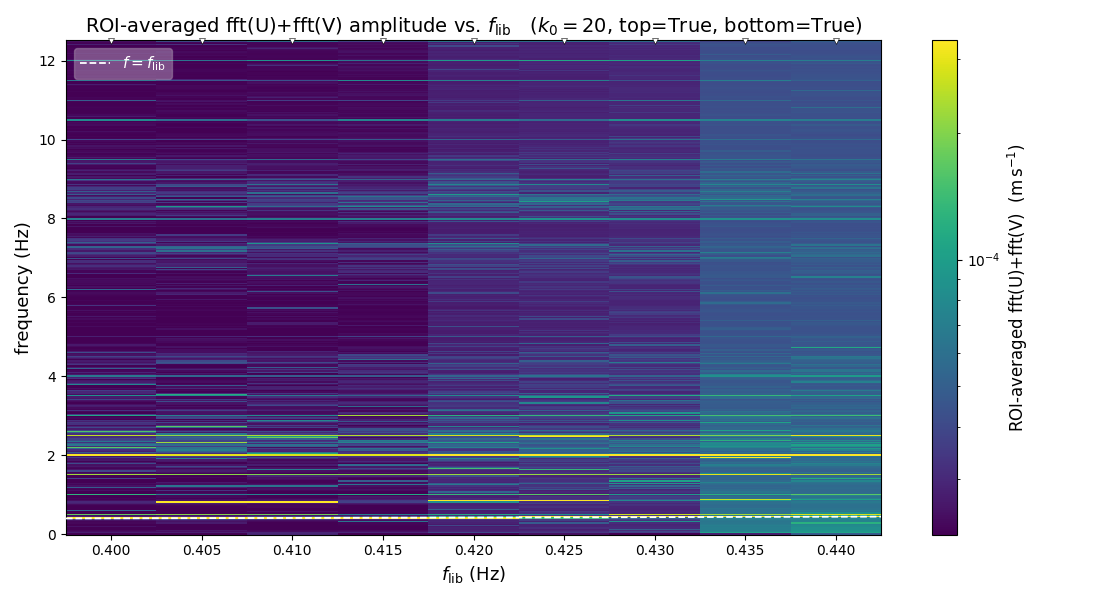

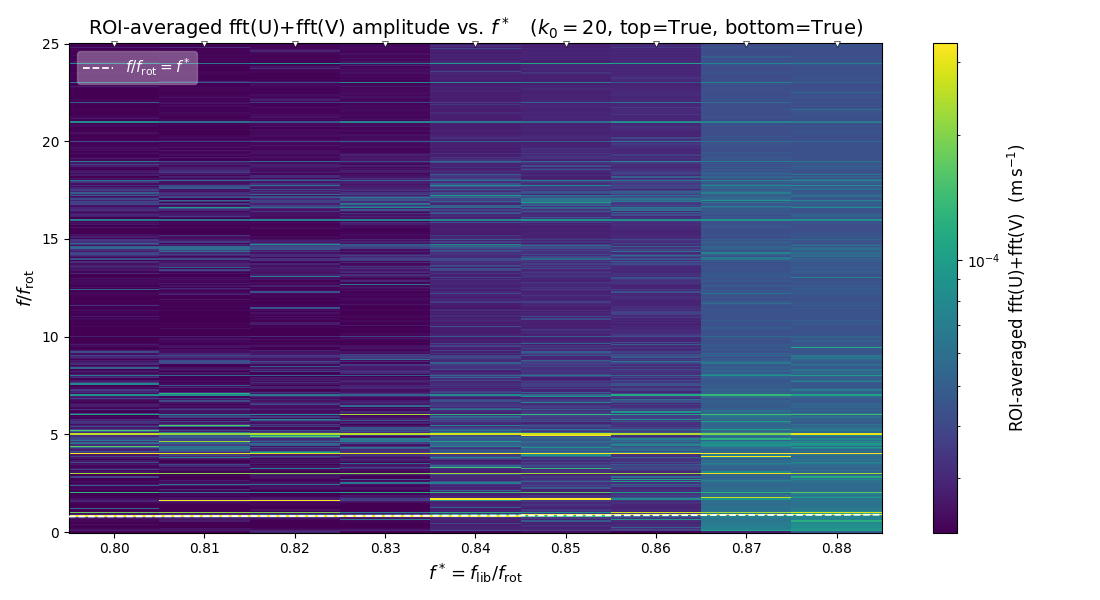

In [8]:
# Returns {region: DataFrame}, one VelocityFFT summary per processed region.
results = run_batch(reprocess_all=REPROCESS_ALL)
next(iter(results.values())).head(40) if results else results


## Colormap vs. $\Delta \phi$ at a fixed $f_{\mathrm{lib}}$

Uses `VelocityFFT_summary.csv` (written by `run_batch`) to list the available
libration frequencies, then plots amplitude with **x = $\delta\phi$**,
**y = $f/f_{\mathrm{rot}}$** at the single $f_{\mathrm{lib}}$ set by
`PLOT_FIX_FLIB` (leave it `None` to take the first available and see the list).
The component follows `PLOT_COMPONENT`.

In [9]:
for _nf in (False, True):
    _ = plot_colormap_dphi(BASE_DIR, REGION_PLOT, flib_hz=PLOT_FIX_FLIB,
                           normalize_freq=_nf)

## Colormap vs. $f_{\mathrm{lib}}$ at a fixed $\Delta\phi$

Mirror of the previous plot with the axes' roles swapped: **x = $f_{\mathrm{lib}}$**,
**y = $f/f_{\mathrm{rot}}$**, at the single $\delta\phi$ set by `PLOT_FIX_DPHI`
(leave it `None` to take the first available and print the list). Component
follows `PLOT_COMPONENT`.

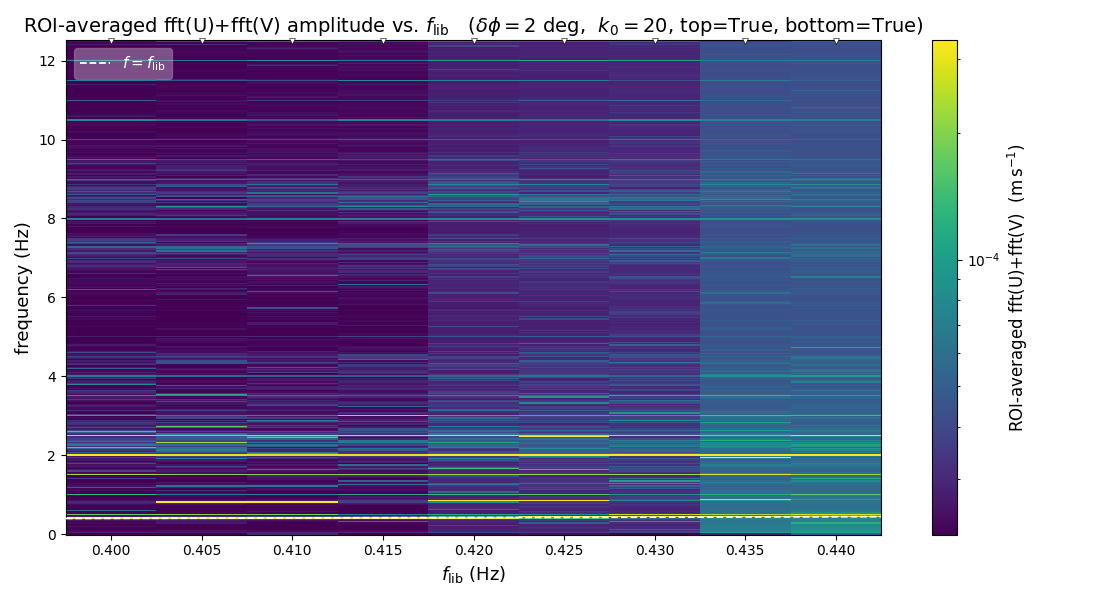

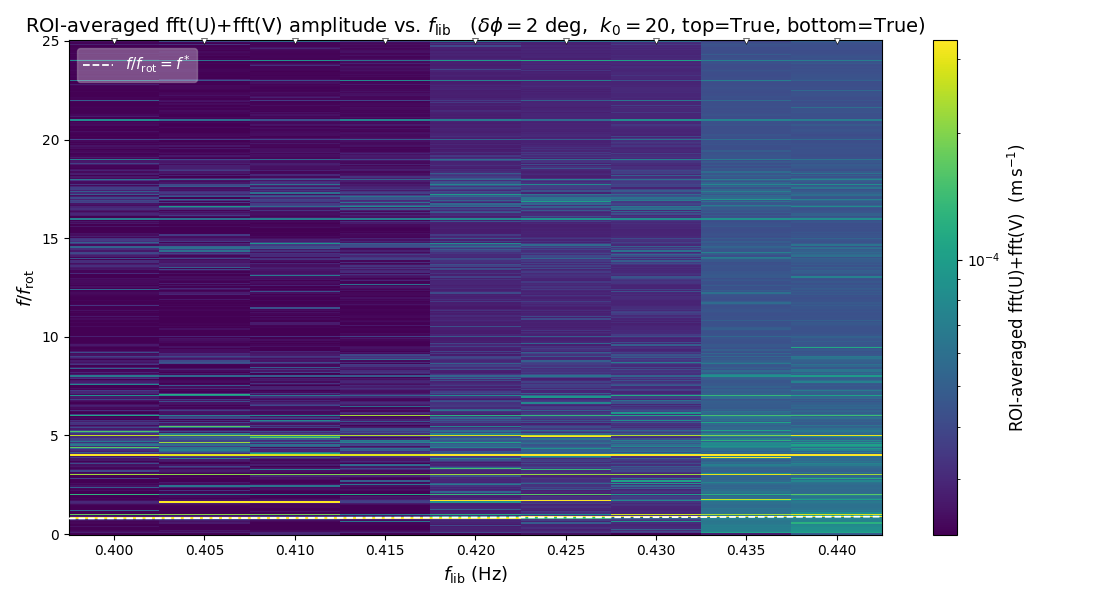

In [10]:
for _nf in (False, True):
    _ = plot_colormap_flib(BASE_DIR, REGION_PLOT, dphi_deg=PLOT_FIX_DPHI,
                           normalize_freq=_nf)